# A5: Heterogeneous regression ensemble

- Train diverse base models with Lasso, Ridge, Random Forest, Gradient Boosting on different bootstrap samples
- Use different feature subsets for diversity
- Aggregate predictions by simple averaging and weighted averaging
- Evaluate against current champion using corrected resampled t-test (explained later)

## 1. Setup & Load Data

In [ ]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sys.path.insert(0, os.getcwd())
from CorrelationFilter import CorrelationFilter

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
DATA_DIR = os.path.join(os.getcwd(), "data")

df_train_original = pd.read_csv(os.path.join(DATA_DIR, "dataset2_train_original.csv"))

# Bootstrap/augmented training sets (for ensemble diversity)
df_train_aug = {}
for i in range(1, 5):  # Use 4 bootstrap samples for 4 base models
    df_train_aug[i] = pd.read_csv(os.path.join(DATA_DIR, f"dataset2_train_augmented_{i}.csv"))

# Held-out test set
df_test = pd.read_csv(os.path.join(DATA_DIR, "dataset2_test.csv"))

print(f"Original train: {df_train_original.shape}")
print(f"Bootstrap samples: {len(df_train_aug)} sets, each ~{df_train_aug[1].shape[0]} rows")
print(f"Test set: {df_test.shape}")

Original train: (1675, 43)
Bootstrap samples: 4 sets, each ~1675 rows
Test set: (419, 43)


In [14]:
# Define target and features
TARGET = "AimoScore"
DROP_COLS = ["ID", "EstimatedScore", TARGET]

# Feature groups
all_cols = [c for c in df_train_original.columns if c not in DROP_COLS]
angle_cols = [c for c in all_cols if "Angle" in c]
nasm_cols = [c for c in all_cols if "NASM" in c]
time_cols = [c for c in all_cols if "Time" in c]

print(f"Total features: {len(all_cols)}")
print(f"Angle features: {len(angle_cols)}")
print(f"NASM features: {len(nasm_cols)}")
print(f"Time features: {len(time_cols)}")

Total features: 40
Angle features: 13
NASM features: 25
Time features: 2


## 2. Define Feature Subsets
Create 4 feature groups with full, angle-only, nasm-only, angle+nasm for ensemble diversity.

In [15]:
# Feature subsets for ensemble diversity
FEATURE_SUBSETS = {
    "full": all_cols,
    "angle_only": angle_cols,
    "nasm_only": nasm_cols,
    "angle_nasm": angle_cols + nasm_cols  # Exclude time
}

for name, cols in FEATURE_SUBSETS.items():
    print(f"{name}: {len(cols)} features")

full: 40 features
angle_only: 13 features
nasm_only: 25 features
angle_nasm: 38 features


## 3. Define Base Models
Configure 4 regressors LassoCV, RidgeCV, RandomForest, and GradientBoosting.

In [ ]:
def get_base_models():
    return {
        "lasso": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=5000))
        ]),
        "ridge": Pipeline([
            ("scaler", StandardScaler()),
            ("model", RidgeCV(cv=5))
        ]),
        "rf": Pipeline([
            ("corrfilter", CorrelationFilter(threshold=0.95)),
            ("model", RandomForestRegressor(
                n_estimators=200, max_depth=15, 
                min_samples_split=5, min_samples_leaf=2,
                random_state=RANDOM_STATE, n_jobs=-1
            ))
        ]),
        "gb": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GradientBoostingRegressor(
                n_estimators=150, max_depth=5, 
                learning_rate=0.1, min_samples_split=5,
                random_state=RANDOM_STATE
            ))
        ])
    }

## 4. Train Base Models on Different Bootstrap Samples
Train each model on a different augmented dataset, evaluate with 5 fold crossvalidation and test set.

In [17]:
def evaluate_model(model, X_test, y_test):
    """Calculate regression metrics."""
    y_pred = model.predict(X_test)
    return {
        "r2": r2_score(y_test, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
        "mae": mean_absolute_error(y_test, y_pred),
        "corr": np.corrcoef(y_test, y_pred)[0, 1]
    }

In [18]:
# Configuration: which model trains on which bootstrap sample with which features
ENSEMBLE_CONFIG = [
    {"name": "lasso", "bootstrap": 1, "features": "full"},
    {"name": "ridge", "bootstrap": 2, "features": "full"},
    {"name": "rf", "bootstrap": 3, "features": "full"},
    {"name": "gb", "bootstrap": 4, "features": "full"},
]

# Prepare test data
X_test = df_test[all_cols].values
y_test = df_test[TARGET].values

# Train models and collect predictions
trained_models = []
test_predictions = []
cv_scores = []

print("Training base models...\n")
print(f"{'Model':<10} {'Bootstrap':<10} {'Features':<12} {'CV R²':<10} {'Test R²':<10} {'Test RMSE':<10}")
print("-" * 65)

for config in ENSEMBLE_CONFIG:
    model_name = config["name"]
    boot_idx = config["bootstrap"]
    feat_name = config["features"]
    feat_cols = FEATURE_SUBSETS[feat_name]
    
    # Get training data from bootstrap sample
    df_train = df_train_aug[boot_idx]
    X_train = df_train[feat_cols].values
    y_train = df_train[TARGET].values
    
    # Get model
    model = get_base_models()[model_name]
    
    # Cross-validation on training data
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_r2 = cross_val_score(model, X_train, y_train, cv=cv, scoring="r2").mean()
    cv_scores.append(cv_r2)
    
    # Train on full bootstrap sample
    model.fit(X_train, y_train)
    
    # Predict on test set (using same feature subset)
    X_test_subset = df_test[feat_cols].values
    y_pred = model.predict(X_test_subset)
    test_predictions.append(y_pred)
    
    # Evaluate
    metrics = evaluate_model(model, X_test_subset, y_test)
    
    trained_models.append({
        "name": model_name,
        "model": model,
        "features": feat_cols,
        "cv_r2": cv_r2,
        "test_metrics": metrics
    })
    
    print(f"{model_name:<10} {boot_idx:<10} {feat_name:<12} {cv_r2:<10.4f} {metrics['r2']:<10.4f} {metrics['rmse']:<10.4f}")

print("\nBase model training complete.")

Training base models...

Model      Bootstrap  Features     CV R²      Test R²    Test RMSE 
-----------------------------------------------------------------
lasso      1          full         0.5496     0.5986     0.1548    
ridge      2          full         0.5864     0.6164     0.1513    
rf         3          full         0.7907     0.7195     0.1294    
gb         4          full         0.7809     0.7307     0.1268    

Base model training complete.


## 5. Ensemble Aggregation
Combine base model predictions using simple averaging and crossvalidation weighted averaging.

In [19]:
# Convert predictions to numpy array
predictions_array = np.array(test_predictions)  # Shape: (n_models, n_samples)

# Simple averaging
y_pred_avg = predictions_array.mean(axis=0)

# Weighted averaging (weights based on CV R² scores)
weights = np.array(cv_scores)
weights = weights / weights.sum()  # Normalize
y_pred_weighted = np.average(predictions_array, axis=0, weights=weights)

print("Ensemble weights (based on CV R²):")
for i, config in enumerate(ENSEMBLE_CONFIG):
    print(f"  {config['name']}: {weights[i]:.4f}")

Ensemble weights (based on CV R²):
  lasso: 0.2030
  ridge: 0.2166
  rf: 0.2920
  gb: 0.2884


In [20]:
# Evaluate ensemble methods
def calc_metrics(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "corr": np.corrcoef(y_true, y_pred)[0, 1]
    }

metrics_avg = calc_metrics(y_test, y_pred_avg)
metrics_weighted = calc_metrics(y_test, y_pred_weighted)

print("\n" + "=" * 60)
print("ENSEMBLE RESULTS")
print("=" * 60)
print(f"\n{'Method':<20} {'R²':<10} {'RMSE':<10} {'MAE':<10} {'Corr':<10}")
print("-" * 60)
print(f"{'Simple Average':<20} {metrics_avg['r2']:<10.4f} {metrics_avg['rmse']:<10.4f} {metrics_avg['mae']:<10.4f} {metrics_avg['corr']:<10.4f}")
print(f"{'Weighted Average':<20} {metrics_weighted['r2']:<10.4f} {metrics_weighted['rmse']:<10.4f} {metrics_weighted['mae']:<10.4f} {metrics_weighted['corr']:<10.4f}")
print("-" * 60)
print(f"{'Current Champion':<20} {'0.6356':<10} {'0.1303':<10} {'0.0972':<10} {'0.8089':<10}")


ENSEMBLE RESULTS

Method               R²         RMSE       MAE        Corr      
------------------------------------------------------------
Simple Average       0.7110     0.1314     0.0988     0.8476    
Weighted Average     0.7204     0.1292     0.0968     0.8535    
------------------------------------------------------------
Current Champion     0.6356     0.1303     0.0972     0.8089    


## 6. Statistical Comparison (Corrected Resampled t-test)
Test if ensemble improvement over champion is statistically significant using Nadeau-Bengio correction.

When you compare two models using cross-validation, you're reusing the same data multiple times since each fold overlaps with others. This makes your results look more precise than they really are. 

As in to say standard t tests assume independent samples, and in crossvalidatoon the same data points appear in multiple train/test splits, which will inflate confidence, so one can claim some form of significant improvement eventho it does not exist

NB correction adds a correction factor which accounts for overlapping samples between folds, which gives a more "honest" confidence interval

ntest/ntrain = 419/1675 is 0.25. so the variance is inflated by about 25% which makes it harder to claim significant improvement. so we use this to be more confident about the improvement

In [21]:
def corrected_resampled_ttest(errors_1, errors_2, n_train, n_test, n_folds=5):
    """
    Corrected resampled t-test for comparing two models.
    Nadeau & Bengio (2003) correction for variance inflation.
    """
    diff = errors_1 - errors_2
    n = len(diff)
    mean_diff = np.mean(diff)
    var_diff = np.var(diff, ddof=1)
    
    # Correction factor
    correction = (1/n) + (n_test / n_train)
    corrected_var = correction * var_diff
    
    # t-statistic
    t_stat = mean_diff / np.sqrt(corrected_var)
    
    # p-value (two-tailed)
    df = n - 1
    p_value = 2 * stats.t.sf(np.abs(t_stat), df)
    
    return t_stat, p_value, mean_diff

In [22]:
# Load current champion for comparison
MODELS_DIR = os.path.join(os.getcwd(), "models")
with open(os.path.join(MODELS_DIR, "aimoscores_improved_A4.pkl"), "rb") as f:
    champion_artifact = pickle.load(f)

champion_model = champion_artifact["model"]
champion_features = champion_artifact["feature_columns"]

# Champion predictions on test set (keep as DataFrame for CorrelationFilter)
X_test_champion = df_test[champion_features]
y_pred_champion = champion_model.predict(X_test_champion)

# Calculate squared errors
errors_champion = (y_test - y_pred_champion) ** 2
errors_avg = (y_test - y_pred_avg) ** 2
errors_weighted = (y_test - y_pred_weighted) ** 2

n_train = len(df_train_original)
n_test = len(df_test)

# T-test: Simple Average vs Champion
t1, p1, diff1 = corrected_resampled_ttest(errors_champion, errors_avg, n_train, n_test)
print(f"Simple Average vs Champion:")
print(f"  Mean MSE difference: {diff1:.6f} (positive = champion worse)")
print(f"  t-statistic: {t1:.4f}")
print(f"  p-value: {p1:.4f}")
print(f"  Significant at α=0.05: {'Yes' if p1 < 0.05 else 'No'}")

print()

# T-test: Weighted Average vs Champion
t2, p2, diff2 = corrected_resampled_ttest(errors_champion, errors_weighted, n_train, n_test)
print(f"Weighted Average vs Champion:")
print(f"  Mean MSE difference: {diff2:.6f} (positive = champion worse)")
print(f"  t-statistic: {t2:.4f}")
print(f"  p-value: {p2:.4f}")
print(f"  Significant at α=0.05: {'Yes' if p2 < 0.05 else 'No'}")

Simple Average vs Champion:
  Mean MSE difference: -0.007098 (positive = champion worse)
  t-statistic: -0.6726
  p-value: 0.5016
  Significant at α=0.05: No

Weighted Average vs Champion:
  Mean MSE difference: -0.006534 (positive = champion worse)
  t-statistic: -0.6376
  p-value: 0.5241
  Significant at α=0.05: No


## 7. Summary & Visualization

In [23]:
# Compare all models
results = []
for m in trained_models:
    results.append({
        "Model": m["name"],
        "R²": m["test_metrics"]["r2"],
        "RMSE": m["test_metrics"]["rmse"],
        "MAE": m["test_metrics"]["mae"]
    })

results.append({"Model": "Ensemble (Avg)", "R²": metrics_avg["r2"], "RMSE": metrics_avg["rmse"], "MAE": metrics_avg["mae"]})
results.append({"Model": "Ensemble (Weighted)", "R²": metrics_weighted["r2"], "RMSE": metrics_weighted["rmse"], "MAE": metrics_weighted["mae"]})
results.append({"Model": "Champion (A4)", "R²": 0.6356, "RMSE": 0.1303, "MAE": 0.0972})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("R²", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

              Model       R²     RMSE      MAE
                 gb 0.730710 0.126801 0.091136
Ensemble (Weighted) 0.720410 0.129203 0.096843
                 rf 0.719510 0.129411 0.094176
     Ensemble (Avg) 0.710973 0.131366 0.098796
      Champion (A4) 0.635600 0.130300 0.097200
              ridge 0.616390 0.151342 0.114280
              lasso 0.598576 0.154816 0.118236


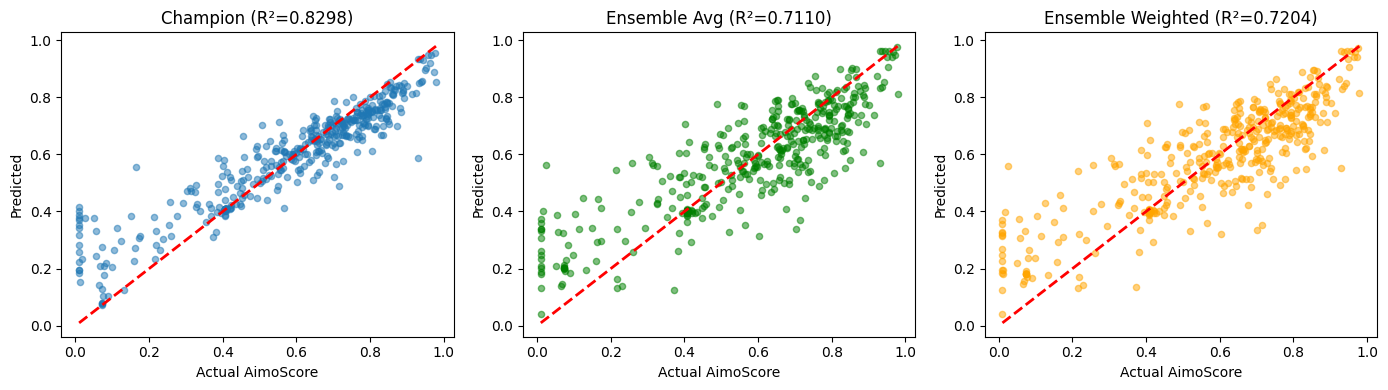

In [24]:
# Visualization: Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Champion
axes[0].scatter(y_test, y_pred_champion, alpha=0.5, s=20)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel("Actual AimoScore")
axes[0].set_ylabel("Predicted")
axes[0].set_title(f"Champion (R²={r2_score(y_test, y_pred_champion):.4f})")

# Simple Average Ensemble
axes[1].scatter(y_test, y_pred_avg, alpha=0.5, s=20, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel("Actual AimoScore")
axes[1].set_ylabel("Predicted")
axes[1].set_title(f"Ensemble Avg (R²={metrics_avg['r2']:.4f})")

# Weighted Average Ensemble
axes[2].scatter(y_test, y_pred_weighted, alpha=0.5, s=20, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel("Actual AimoScore")
axes[2].set_ylabel("Predicted")
axes[2].set_title(f"Ensemble Weighted (R²={metrics_weighted['r2']:.4f})")

plt.tight_layout()
plt.show()

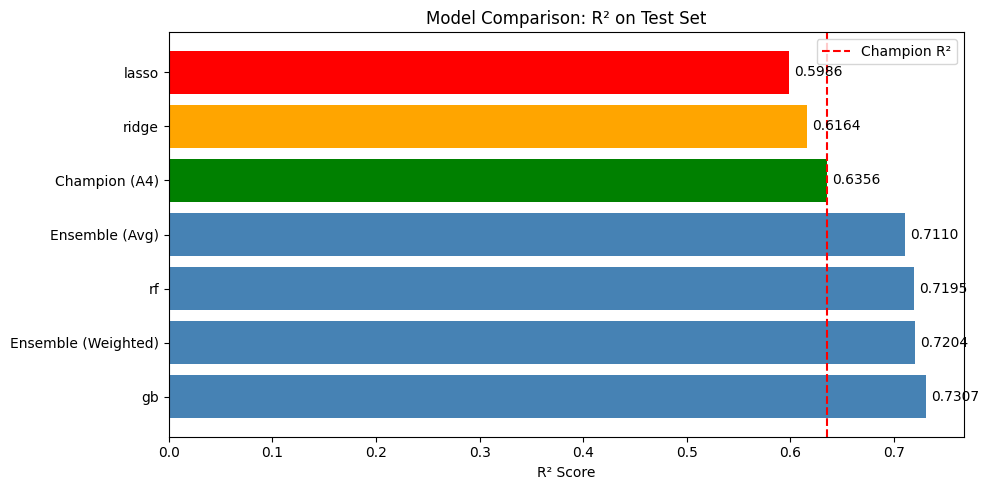

In [25]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(10, 5))

models = results_df["Model"].tolist()
r2_values = results_df["R²"].tolist()
colors = ['steelblue'] * (len(models) - 3) + ['green', 'orange', 'red']

bars = ax.barh(models, r2_values, color=colors)
ax.axvline(x=0.6356, color='red', linestyle='--', label='Champion R²')
ax.set_xlabel("R² Score")
ax.set_title("Model Comparison: R² on Test Set")
ax.legend()

for bar, val in zip(bars, r2_values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center')

plt.tight_layout()
plt.show()

## 8. Save Best Model 
Pickle the ensemble artifact to A5/models/ if it outperforms the current champion.

In [26]:
# Determine best ensemble
best_ensemble_r2 = max(metrics_avg["r2"], metrics_weighted["r2"])
best_ensemble_name = "weighted" if metrics_weighted["r2"] > metrics_avg["r2"] else "average"
best_ensemble_pred = y_pred_weighted if best_ensemble_name == "weighted" else y_pred_avg
best_metrics = metrics_weighted if best_ensemble_name == "weighted" else metrics_avg

CHAMPION_R2 = 0.6356

print(f"Best ensemble: {best_ensemble_name} (R²={best_ensemble_r2:.4f})")
print(f"Champion R²: {CHAMPION_R2:.4f}")
print(f"Improvement: {best_ensemble_r2 - CHAMPION_R2:.4f}")

if best_ensemble_r2 > CHAMPION_R2:
    print("\n✓ Ensemble beats champion! Saving new model...")
    
    # Create ensemble artifact
    ensemble_artifact = {
        "models": trained_models,
        "weights": weights.tolist() if best_ensemble_name == "weighted" else None,
        "aggregation": best_ensemble_name,
        "feature_columns": all_cols,
        "target": TARGET,
        "train_metrics": {
            "cv_r2_mean": np.mean(cv_scores)
        },
        "test_metrics": best_metrics
    }
    
    output_path = os.path.join(MODELS_DIR, "aimoscores_ensemble_A5.pkl")
    with open(output_path, "wb") as f:
        pickle.dump(ensemble_artifact, f)
    
    print(f"Saved to: {output_path}")
else:
    print("\n✗ Ensemble does not beat champion. No model saved.")

Best ensemble: weighted (R²=0.7204)
Champion R²: 0.6356
Improvement: 0.0848

✓ Ensemble beats champion! Saving new model...
Saved to: /Users/amol/Desktop/LNU/LNU_Masters/intensive/github/Data-intensive-systems/A5/models/aimoscores_ensemble_A5.pkl


## 9. Conclusion
Summary of ensemble results and statistical significance findings.

In [27]:
print("=" * 60)
print("A5 HETEROGENEOUS REGRESSION ENSEMBLE - SUMMARY")
print("=" * 60)
print(f"\nBase models trained: {len(trained_models)}")
print(f"  - Lasso, Ridge, RandomForest, GradientBoosting")
print(f"  - Each trained on different bootstrap sample")
print(f"\nEnsemble methods tested:")
print(f"  - Simple averaging: R²={metrics_avg['r2']:.4f}")
print(f"  - Weighted averaging: R²={metrics_weighted['r2']:.4f}")
print(f"\nCurrent champion: R²={CHAMPION_R2:.4f}")
print(f"\nStatistical significance (α=0.05):")
print(f"  - Simple Avg vs Champion: p={p1:.4f} ({'Significant' if p1 < 0.05 else 'Not significant'})")
print(f"  - Weighted Avg vs Champion: p={p2:.4f} ({'Significant' if p2 < 0.05 else 'Not significant'})")
print("=" * 60)

A5 HETEROGENEOUS REGRESSION ENSEMBLE - SUMMARY

Base models trained: 4
  - Lasso, Ridge, RandomForest, GradientBoosting
  - Each trained on different bootstrap sample

Ensemble methods tested:
  - Simple averaging: R²=0.7110
  - Weighted averaging: R²=0.7204

Current champion: R²=0.6356

Statistical significance (α=0.05):
  - Simple Avg vs Champion: p=0.5016 (Not significant)
  - Weighted Avg vs Champion: p=0.5241 (Not significant)
